In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [ ]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df['Car_Age'] = 2025 - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [8]:
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [9]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [10]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(X.shape)
print(y.shape)

(301, 8)
(301,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (240, 8)
Testing Data: (61, 8)


In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 0.4438, 10.9098,  4.9315,  0.2159,  7.7988,  6.2535,  1.1065,
        0.5876,  0.469 ,  6.896 ])

In [14]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae, 2))
print("Root Mean Squared Error :", round(rmse, 2))
print("R2 Score :", round(r2, 2))

Mean Absolute Error : 0.64
Root Mean Squared Error : 0.97
R2 Score : 0.96


In [15]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
177,0.35,0.4438
289,10.11,10.9098
228,4.95,4.9315
198,0.15,0.2159
60,6.95,7.7988
9,7.45,6.2535
118,1.10,1.1065
154,0.50,0.5876
164,0.45,0.4690
33,6.00,6.8960


In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

,0
Present_Price,0.881166
Car_Age,0.059495
Driven_kms,0.040265
Transmission_Manual,0.009646
Fuel_Type_Diesel,0.004339
Fuel_Type_Petrol,0.002564
Selling_type_Individual,0.002155
Owner,0.000370


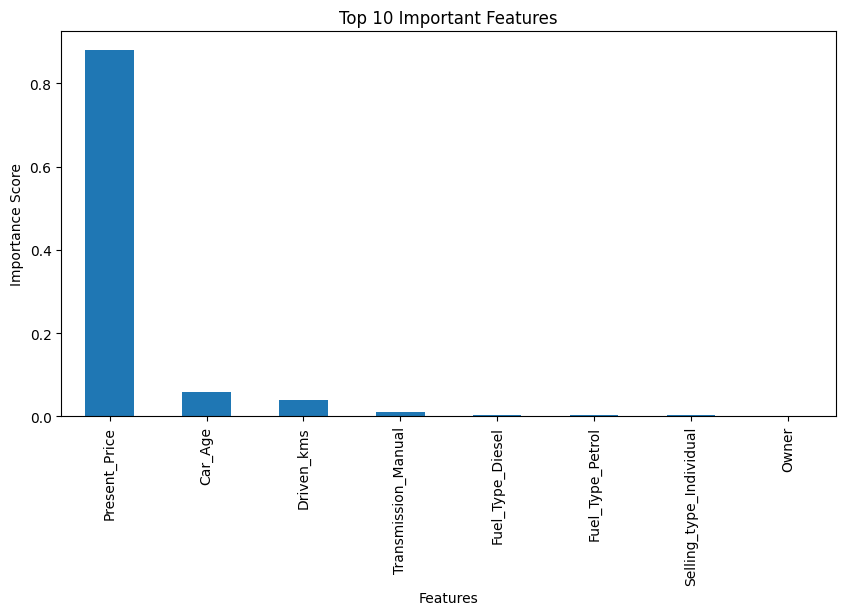

In [17]:
importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

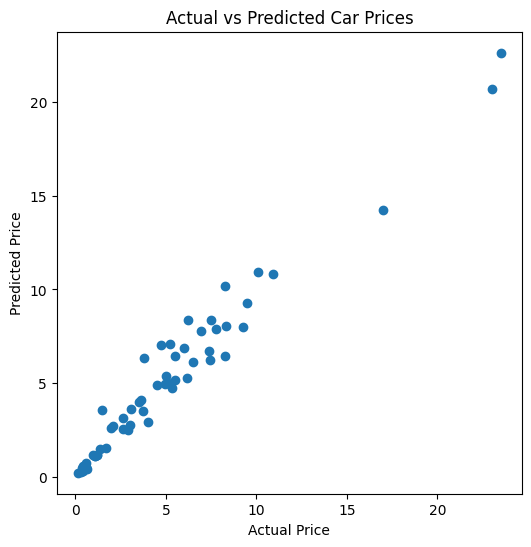

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [19]:
print("""
Project Completed Successfully

✔ Data Preprocessing
✔ Feature Engineering
✔ Regression Model Training
✔ Model Evaluation
✔ Visualization

Machine Learning Model Used:
Random Forest Regressor
""")


Project Completed Successfully

✔ Data Preprocessing
✔ Feature Engineering
✔ Regression Model Training
✔ Model Evaluation
✔ Visualization

Machine Learning Model Used:
Random Forest Regressor

